In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [2]:
data = np.array(data)
# First column represents the label for each training example
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets
# "dev set" (short for development set) is just another widely used term
# for the validation set.

data_dev = data[0:1000].T

# After transpose, data_dev has a total of 785 rows and 1,000 columns, 
# where each column represents a new example and all rows for a specific column
# represent its features (pixel values). In the dataset originally, the first
# column represented the accurate labels for each training example, but after
# transpose, that row of labels is extracted into a 1D array using data_dev[0]


Y_dev = data_dev[0]
# very first row (index 0), which now contains the labels for all 1,000 examples.
# Y_dev is a 1D array (a flat vector) containing 1,000 elements.

X_dev = data_dev[1:n]
X_dev = X_dev / 255.
# Normalization happened. scale all of those pixel vals to a range bween 0.0&1.0

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [3]:
Y_dev.shape

(1000,)

In [4]:
data_dev.shape

(785, 1000)

In [5]:
Y_train

array([2, 7, 9, ..., 6, 8, 8])

In [6]:
X_train.shape

(784, 41000)

In [7]:
X_train[:,0].shape
# rabs all 784 pixel values for the very first training example (index 0) 
#out of your 41,000 total examples.

(784,)

Our NN will have a simple two-layer architecture. Input layer $a^{[0]}$ will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer $a^{[1]}$ will have 10 units with ReLU activation, and finally our output layer $a^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**Forward propagation**

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = g_{\text{ReLU}}(Z^{[1]}))$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = g_{\text{softmax}}(Z^{[2]})$$

**Backward propagation**

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} .* g^{[1]\prime} (z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} A^{[0]T}$$
$$dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Parameter updates**

$$W^{[2]} := W^{[2]} - \alpha dW^{[2]}$$
$$b^{[2]} := b^{[2]} - \alpha db^{[2]}$$
$$W^{[1]} := W^{[1]} - \alpha dW^{[1]}$$
$$b^{[1]} := b^{[1]} - \alpha db^{[1]}$$

**Vars and shapes**

Forward prop

- $A^{[0]} = X$: 784 x m
- $Z^{[1]} \sim A^{[1]}$: 10 x m
- $W^{[1]}$: 10 x 784 (as $W^{[1]} A^{[0]} \sim Z^{[1]}$)
- $B^{[1]}$: 10 x 1
- $Z^{[2]} \sim A^{[2]}$: 10 x m
- $W^{[1]}$: 10 x 10 (as $W^{[2]} A^{[1]} \sim Z^{[2]}$)
- $B^{[2]}$: 10 x 1

Backprop

- $dZ^{[2]}$: 10 x m ($~A^{[2]}$)
- $dW^{[2]}$: 10 x 10
- $dB^{[2]}$: 10 x 1
- $dZ^{[1]}$: 10 x m ($~A^{[1]}$)
- $dW^{[1]}$: 10 x 10
- $dB^{[1]}$: 10 x 1

In [8]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    
    # 10 Rows = 10 Neurons: Each row belongs entirely to one specific neuron in the hidden layer. 
    # 784 Columns = 784 Weights: Because every single neuron needs to look at 
    # every single input pixel from the image, each neuron (row) holds exactly 
    # 784 unique weights.
    
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

# The one_hot(Y) function is designed to convert a 1D array of class labels
# (like [0, 1, 2]) into a 2D one-hot encoded matrix. The main purpose of the 
# one_hot(Y) function is to format your target labels so they can be directly 
# compared against the neural network's predictions during training.

# one_hot_Y is the ground truth

def one_hot(Y):
    # np.zeros ((examples, 10))
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    # indexing to target exactly one element per row and flip it from 0 to 1.
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    # This final shape `(10, m)` matches your network's output activation layer
    # `A2`, allowing you to directly subtract them in backpropagation 
    # (`dZ2 = A2 - one_hot_Y`)
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [9]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [10]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[0 1 9 ... 9 1 2] [2 7 9 ... 6 8 8]
0.10563414634146341
Iteration:  10
[4 1 9 ... 9 7 2] [2 7 9 ... 6 8 8]
0.1747560975609756
Iteration:  20
[0 1 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.298
Iteration:  30
[0 1 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.3662439024390244
Iteration:  40
[0 1 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.4066341463414634
Iteration:  50
[0 1 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.44278048780487805
Iteration:  60
[0 7 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.47848780487804876
Iteration:  70
[0 7 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.5120975609756098
Iteration:  80
[0 7 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.5438536585365854
Iteration:  90
[0 7 9 ... 6 7 1] [2 7 9 ... 6 8 8]
0.5745853658536585
Iteration:  100
[2 7 9 ... 6 7 8] [2 7 9 ... 6 8 8]
0.6015609756097561
Iteration:  110
[2 7 9 ... 6 7 8] [2 7 9 ... 6 8 8]
0.6262439024390244
Iteration:  120
[2 7 9 ... 6 7 8] [2 7 9 ... 6 8 8]
0.6489512195121951
Iteration:  130
[2 7 9 ... 6 7 8] [2 7 9 ... 6 8 8]
0.6676341463414635
Iteration:  140
[2 7 9 ... 

~85% accuracy on training set.

In [11]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Let's look at a couple of examples:

Prediction:  [2]
Label:  2


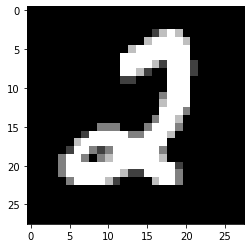

Prediction:  [7]
Label:  7


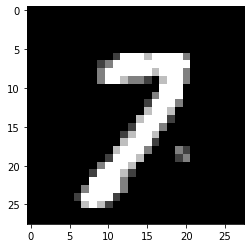

Prediction:  [9]
Label:  9


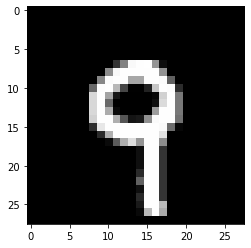

Prediction:  [7]
Label:  7


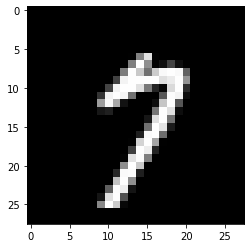

In [12]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Finally, let's find the accuracy on the dev set:

In [13]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[3 5 9 3 5 9 6 4 9 9 7 5 1 1 8 9 0 7 1 8 0 3 3 8 3 6 5 5 6 7 4 3 3 9 5 2 8
 3 3 1 2 1 1 8 8 2 9 8 7 7 1 5 8 3 9 6 9 4 8 8 6 7 4 9 4 2 0 6 5 0 6 9 3 1
 0 9 6 2 1 1 1 6 6 2 1 6 4 8 8 7 0 1 7 9 7 3 8 0 1 5 6 3 5 9 2 8 8 3 1 9 2
 0 6 3 1 2 2 2 3 4 9 7 6 2 6 6 6 6 4 5 9 1 5 7 4 4 7 9 9 3 8 8 5 9 4 6 1 8
 1 0 9 6 2 7 2 9 2 5 3 7 2 7 3 1 3 2 4 2 4 3 4 8 2 2 0 8 9 8 2 5 2 4 9 5 8
 1 4 5 2 6 2 0 7 4 4 9 3 9 9 3 7 7 5 1 2 6 6 9 2 8 9 7 0 7 5 1 5 3 6 3 7 1
 3 1 3 3 3 3 6 4 7 4 4 8 2 4 0 6 8 7 8 6 3 1 7 4 4 0 1 2 8 6 8 6 1 5 2 7 3
 0 9 4 3 6 6 9 0 8 2 0 3 8 2 7 1 1 7 9 9 7 3 6 1 1 0 6 7 5 9 5 2 1 0 2 9 0
 0 9 6 1 8 5 2 6 5 1 0 7 9 7 0 5 7 8 1 3 7 0 3 0 4 3 9 7 0 7 6 1 7 6 2 8 4
 5 3 3 9 1 3 5 5 1 4 7 3 3 4 4 9 9 1 0 4 7 4 9 2 4 5 4 7 4 6 6 0 1 1 2 5 1
 8 2 9 1 0 4 9 4 2 6 9 7 6 0 1 4 8 8 0 6 4 7 0 7 1 4 5 7 2 8 5 9 1 1 9 0 9
 2 4 1 0 2 6 6 9 1 9 1 7 1 1 5 7 5 9 2 3 2 8 4 4 2 4 5 8 9 3 7 2 7 7 5 4 7
 8 1 3 4 1 0 3 5 9 9 3 7 9 8 8 0 8 4 6 6 2 6 0 7 6 1 7 8 1 9 8 6 6 3 0 6 0
 1 3 9 4 1 9 1 1 1 4 5 7 

0.862

Still 84% accuracy, so our model generalized from the training data pretty well.